In [1]:
import numpy as np
import matplotlib.pyplot as plt

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2*(h[i-1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6*(((y[i + 1]-y[i])/h[i]) - (y[i] - y[i - 1]) / h[i - 1]) # Right-hand side vector
    return A, B, C, D

In [2]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [3]:
def evaluate_spline(x, y, xeval, M):
    h = np.diff(x)
    for i in range(len(x) - 1):
        if xeval >= x[i] and xeval <= x[i + 1]:
            a = y[i]
            b = ((y[i + 1] - y[i]) / h[i]) - (h[i] / 6) * (M[i + 1] + 2 * M[i])
            c = M[i] / 2
            d = (M[i + 1] - M[i]) / (6 * h[i])
            
            yeval = a + b*(xeval - x[i]) + c*((xeval - x[i])**2) + d*((xeval - x[i])**3)
    return yeval

In [4]:
def evaluate_spline_new(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

In [5]:
# Example data points
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])
# Set up the tridiagonal matrix for the cubic spline
A, B, C, D = setup_tridiagonal_matrix(x, y)

M = np.zeros(len(x))
M[1:-1] = thomas_algorithm(A, B, C, D)

x_interp = np.arange(x[0], x[-1], 0.01)
y_interp = evaluate_spline_new(x, y, M, x_interp)

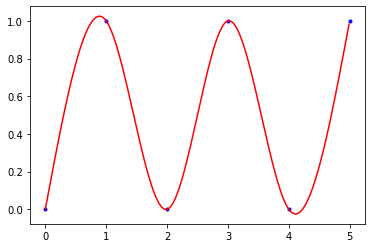

In [6]:
plt.plot(x, y, 'b.')
plt.plot(x_interp, y_interp, 'r-')
plt.show()